# Contribution 1 Evidence

Guardrails Admission improves hit ratio while stabilizing admission.

This notebook produces:
- HR vs cache size (LRU, LRU-K, GDBT, IL-no-guard, IL-guard)
- Summary table: avg HR, avg ΔHR, RMR, win/tie/lose
- Pollution, insertion rate, hit-yield vs cache size (Guard vs No-Guard)


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve project root (works from repo root or /notebooks)
PROJECT_ROOT = Path.cwd().resolve()
for _ in range(4):
    if (PROJECT_ROOT / 'results').exists() and (PROJECT_ROOT / 'src').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_ROOT = PROJECT_ROOT / 'results'
FIG_DIR = RESULTS_ROOT / 'figures'
TAB_DIR = RESULTS_ROOT / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'wikipedia_september_2007': RESULTS_ROOT / 'wikipedia_september_2007',
    'wiki2018': RESULTS_ROOT / 'wiki2018',
}

FEATURE_SET = 'A2'
RUN_PREFIX = '001'

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})


In [2]:
def load_summary_json(path: Path):
    with path.open() as f:
        return json.load(f)


def list_sizes(root: Path, pattern: str):
    sizes = set()
    for p in root.glob(pattern):
        try:
            sizes.add(int(p.stem.split('_')[-1]))
        except Exception:
            pass
    return sorted(sizes)


def load_il_summary(root: Path, variant: str, size: int):
    p = root / f"{RUN_PREFIX}_summary_ilnse_{FEATURE_SET}_{variant}_{size}.json"
    return load_summary_json(p)


def collect_baselines(root: Path, dataset: str):
    rows = []
    # LRU / LRU-K / TinyLFU
    for p in root.glob(f"{RUN_PREFIX}_summary_baseline_*_*.json"):
        s = load_summary_json(p)
        policy = s.get('policy', '').upper()
        if policy == 'LRU':
            method = 'LRU'
        elif policy in ('LRU-K', 'LRUK', 'LRU_K'):
            method = 'LRU-K'
        elif policy == 'TINYLFU':
            method = 'TinyLFU'
        else:
            continue
        rows.append({
            'dataset': dataset,
            'method': method,
            'cache_size': s.get('cache_size_objects') or s.get('cache_size'),
            'hit_ratio': s.get('hit_ratio')
        })

    # GDBT (A2)
    for p in root.glob(f"{RUN_PREFIX}_summary_gdbt_{FEATURE_SET}_*.json"):
        s = load_summary_json(p)
        rows.append({
            'dataset': dataset,
            'method': 'GBDT',
            'cache_size': s.get('cache_size_objects') or s.get('cache_size'),
            'hit_ratio': s.get('hit_ratio')
        })

    return pd.DataFrame(rows)


def collect_guard_variants(root: Path, dataset: str):
    rows = []
    for variant, label in [
        ('guard_no_guard_NB', 'IL-no-guard'),
        ('guard_full_NB', 'IL-guard')
    ]:
        sizes = list_sizes(root, f"{RUN_PREFIX}_summary_ilnse_{FEATURE_SET}_{variant}_*.json")
        for size in sizes:
            s = load_il_summary(root, variant, size)
            rows.append({
                'dataset': dataset,
                'method': label,
                'cache_size': size,
                'hit_ratio': s.get('hit_ratio')
            })
    return pd.DataFrame(rows)



In [3]:
# Build overall comparison table
all_rows = []
for dataset, root in DATASETS.items():
    all_rows.append(collect_baselines(root, dataset))
    all_rows.append(collect_guard_variants(root, dataset))

overall = pd.concat(all_rows, ignore_index=True)
overall.head()


,dataset,method,cache_size,hit_ratio
0,wikipedia_september_2007,LRU,45831,0.646844
1,wikipedia_september_2007,TinyLFU,45831,0.663195
2,wikipedia_september_2007,LRU-K,45831,0.669704
3,wikipedia_september_2007,LRU,61109,0.661164
4,wikipedia_september_2007,LRU,12221,0.587661


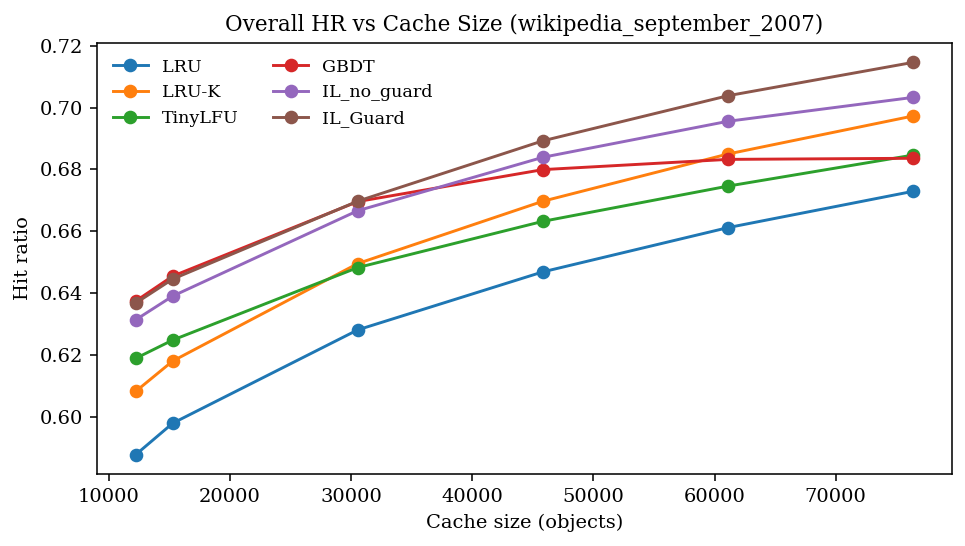

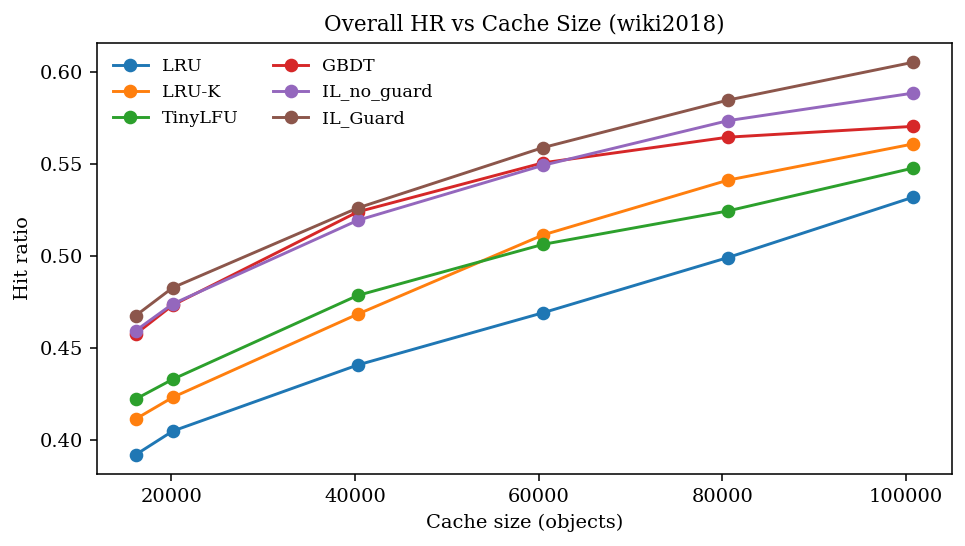

In [4]:
# Figure 1: HR vs cache size (overall comparison)
method_order = ['LRU', 'LRU-K', 'TinyLFU', 'GBDT', 'IL-no-guard', 'IL-guard']

for dataset in DATASETS.keys():
    data = overall[overall['dataset'] == dataset].copy()
    data['method'] = data['method'].replace({
        'IL_no_guard': 'IL-no-guard',
        'IL_Guard': 'IL-guard',
        'IL_guard': 'IL-guard'
    })
    fig, ax = plt.subplots(figsize=(7.0, 4.0))
    for method in method_order:
        g = data[data['method'] == method]
        if g.empty:
            continue
        g = g.sort_values('cache_size')
        ax.plot(g['cache_size'], g['hit_ratio'], marker='o', label=method)

    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('Hit ratio')
    ax.set_title(f'Overall HR vs Cache Size ({dataset})')
    ax.legend(loc='best', frameon=False, ncol=2)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'cont1_overall_hr_{dataset}.png')
    fig.savefig(FIG_DIR / f'cont1_overall_hr_{dataset}.pdf')
    plt.show()
    plt.close(fig)



In [5]:
# Table 1: Summary HR gain, RMR, win/tie/lose counts
rows = []
for dataset, root in DATASETS.items():
    sizes = list_sizes(root, f"{RUN_PREFIX}_summary_ilnse_{FEATURE_SET}_guard_full_NB_*.json")
    wins = ties = losses = 0
    dhrs = []
    rmrs = []
    hr_full = []
    hr_nog = []

    for size in sizes:
        s_full = load_il_summary(root, 'guard_full_NB', size)
        s_nog = load_il_summary(root, 'guard_no_guard_NB', size)
        h_full = s_full.get('hit_ratio')
        h_nog = s_nog.get('hit_ratio')
        if h_full is None or h_nog is None:
            continue
        hr_full.append(h_full)
        hr_nog.append(h_nog)
        d = h_full - h_nog
        dhrs.append(d)
        denom = max(1e-12, 1.0 - h_nog)
        rmrs.append(d / denom)
        if abs(d) < 1e-6:
            ties += 1
        elif d > 0:
            wins += 1
        else:
            losses += 1

    rows.append({
        'dataset': dataset,
        'avg_hr_guard': float(np.mean(hr_full)),
        'avg_hr_no_guard': float(np.mean(hr_nog)),
        'avg_delta_hr': float(np.mean(dhrs)),
        'avg_rmr': float(np.mean(rmrs)),
        'win': wins,
        'tie': ties,
        'lose': losses,
    })

summary_table = pd.DataFrame(rows)
summary_table.to_csv(TAB_DIR / 'cont1_summary_table.csv', index=False)
summary_table.to_latex(TAB_DIR / 'cont1_summary_table.tex', index=False, float_format='%.6f')
summary_table


/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_69099/2678153566.py:44: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  summary_table.to_latex(TAB_DIR / 'cont1_summary_table.tex', index=False, float_format='%.6f')


,dataset,avg_hr_guard,avg_hr_no_guard,avg_delta_hr,avg_rmr,win,tie,lose
0,wikipedia_september_2007,0.676448,0.669959,0.006489,0.020234,6,0,0
1,wiki2018,0.537505,0.527302,0.010203,0.022338,6,0,0


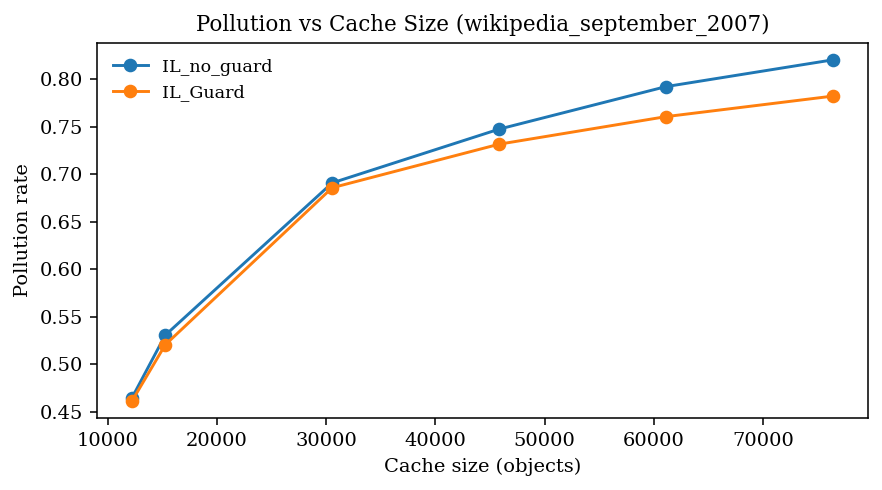

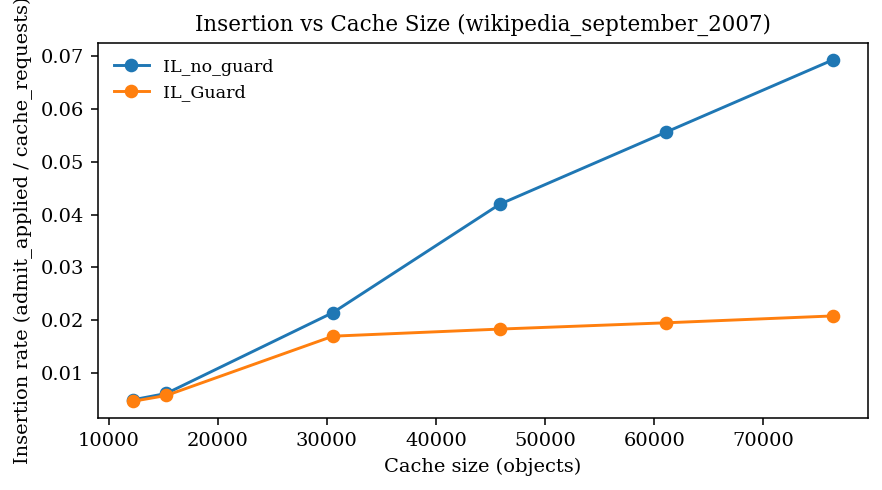

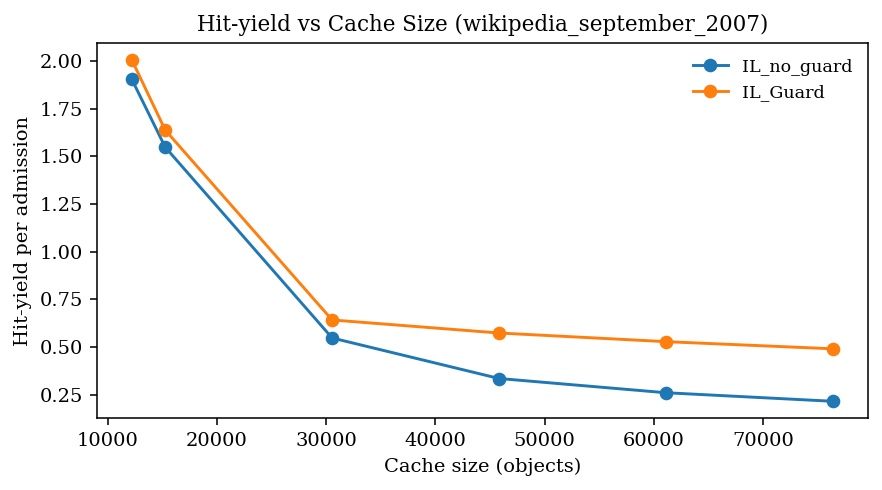

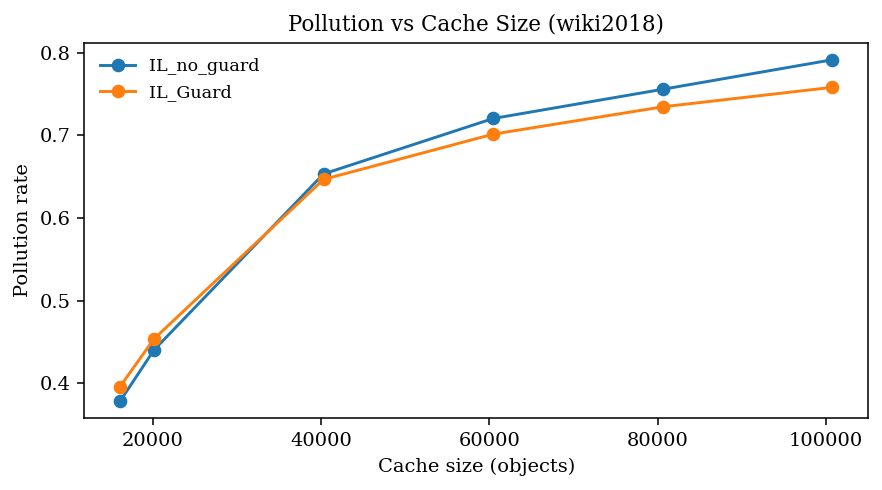

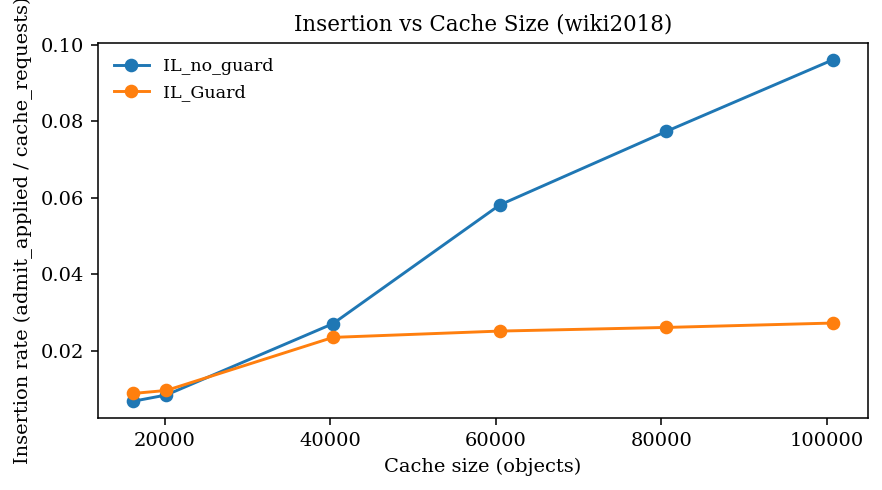

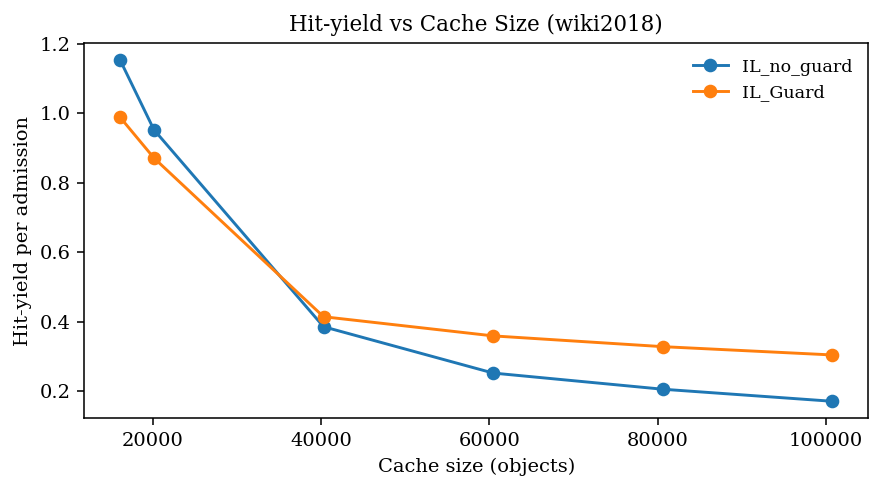

In [6]:
# Pollution / insertion / hit-yield vs cache size (Guard vs No-Guard)

def build_metric_df(root: Path, dataset: str, variant: str):
    sizes = list_sizes(root, f"{RUN_PREFIX}_summary_ilnse_{FEATURE_SET}_{variant}_*.json")
    rows = []
    for size in sizes:
        s = load_il_summary(root, variant, size)
        rows.append({
            'dataset': dataset,
            'variant': variant,
            'cache_size': size,
            'pollution_rate_total': s.get('pollution_rate_total'),
            'hit_yield_total': s.get('hit_yield_total'),
            'admit_applied_total': s.get('admit_applied_total'),
            'cache_requests': s.get('cache_requests'),
        })
    df = pd.DataFrame(rows)
    df['insertion_rate'] = df['admit_applied_total'] / df['cache_requests']
    return df

metrics = []
for dataset, root in DATASETS.items():
    metrics.append(build_metric_df(root, dataset, 'guard_no_guard_NB'))
    metrics.append(build_metric_df(root, dataset, 'guard_full_NB'))

metrics = pd.concat(metrics, ignore_index=True)

for dataset in DATASETS.keys():
    data = metrics[metrics['dataset'] == dataset]

    # Pollution
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    for variant, label in [('guard_no_guard_NB','IL-no-guard'), ('guard_full_NB','IL-guard')]:
        g = data[data['variant'] == variant].sort_values('cache_size')
        ax.plot(g['cache_size'], g['pollution_rate_total'], marker='o', label=label)
    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('Pollution rate')
    ax.set_title(f'Pollution vs Cache Size ({dataset})')
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'cont1_pollution_{dataset}.png')
    fig.savefig(FIG_DIR / f'cont1_pollution_{dataset}.pdf')
    plt.show()
    plt.close(fig)

    # Insertion rate
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    for variant, label in [('guard_no_guard_NB','IL-no-guard'), ('guard_full_NB','IL-guard')]:
        g = data[data['variant'] == variant].sort_values('cache_size')
        ax.plot(g['cache_size'], g['insertion_rate'], marker='o', label=label)
    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('Insertion rate (admit_applied / cache_requests)')
    ax.set_title(f'Insertion vs Cache Size ({dataset})')
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'cont1_insertion_{dataset}.png')
    fig.savefig(FIG_DIR / f'cont1_insertion_{dataset}.pdf')
    plt.show()
    plt.close(fig)

    # Hit-yield
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    for variant, label in [('guard_no_guard_NB','IL-no-guard'), ('guard_full_NB','IL-guard')]:
        g = data[data['variant'] == variant].sort_values('cache_size')
        ax.plot(g['cache_size'], g['hit_yield_total'], marker='o', label=label)
    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('Hit-yield per admission')
    ax.set_title(f'Hit-yield vs Cache Size ({dataset})')
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'cont1_hit_yield_{dataset}.png')
    fig.savefig(FIG_DIR / f'cont1_hit_yield_{dataset}.pdf')
    plt.show()
    plt.close(fig)


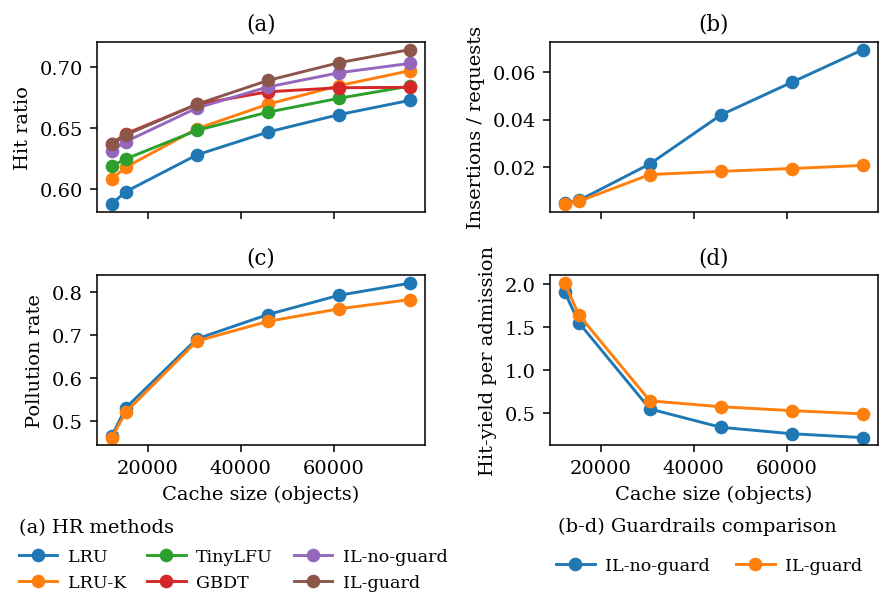

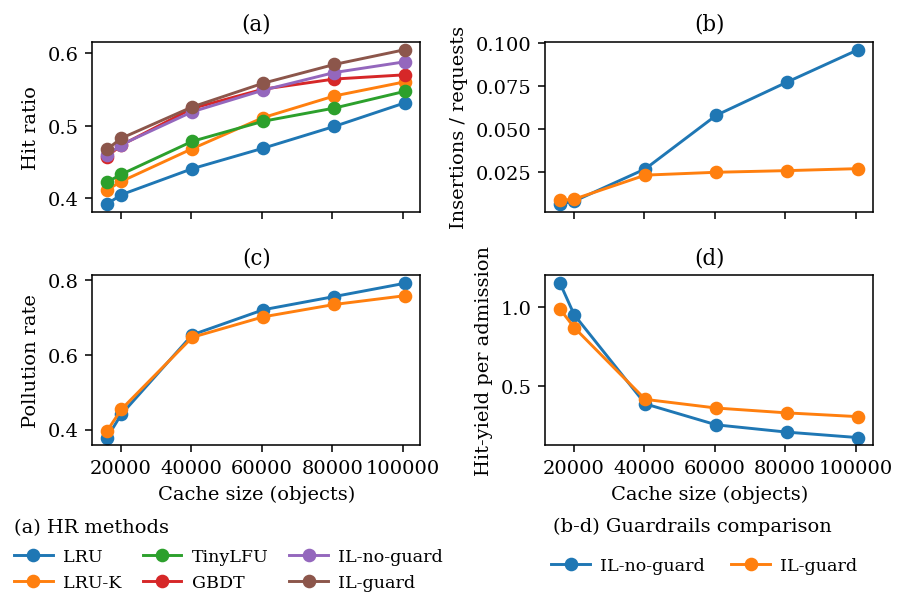

In [11]:
# Option A: multi-panel (2x2) figure per trace with clean legend strip
for dataset in DATASETS.keys():
    fig = plt.figure(figsize=(7.2, 5.8))
    gs = fig.add_gridspec(
        3, 2,
        height_ratios=[1, 1, 0.50],
        hspace=0.45, wspace=0.38
    )

    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[1, 0])
    ax_d = fig.add_subplot(gs[1, 1])
    ax_leg = fig.add_subplot(gs[2, :])
    ax_leg.axis('off')

    # (a) HR vs cache size (overall)
    data = overall[overall['dataset'] == dataset].copy()
    data['method'] = data['method'].replace({
        'IL_no_guard': 'IL-no-guard',
        'IL_Guard': 'IL-guard',
        'IL_guard': 'IL-guard'
    })
    for method in ['LRU', 'LRU-K', 'TinyLFU', 'GBDT', 'IL-no-guard', 'IL-guard']:
        g = data[data['method'] == method]
        if g.empty:
            continue
        g = g.sort_values('cache_size')
        ax_a.plot(g['cache_size'], g['hit_ratio'], marker='o', label=method)
    # ax_a.set_title('(a) HR vs cache size')
    ax_a.set_title('(a)')
    ax_a.set_ylabel('Hit ratio')

    # (b) Insertion rate
    data_m = metrics[metrics['dataset'] == dataset]
    for variant, label in [('guard_no_guard_NB','IL-no-guard'), ('guard_full_NB','IL-guard')]:
        g = data_m[data_m['variant'] == variant].sort_values('cache_size')
        ax_b.plot(g['cache_size'], g['insertion_rate'], marker='o', label=label)
    # ax_b.set_title('(b) Insertion rate')
    ax_b.set_title('(b)')
    ax_b.set_ylabel('Insertions / requests')

    # (c) Pollution
    for variant, label in [('guard_no_guard_NB','IL-no-guard'), ('guard_full_NB','IL-guard')]:
        g = data_m[data_m['variant'] == variant].sort_values('cache_size')
        ax_c.plot(g['cache_size'], g['pollution_rate_total'], marker='o', label=label)
    # ax_c.set_title('(c) Pollution proxy')
    ax_c.set_title('(c)')
    ax_c.set_xlabel('Cache size (objects)')
    ax_c.set_ylabel('Pollution rate')
    

    # (d) Hit-yield
    for variant, label in [('guard_no_guard_NB','IL-no-guard'), ('guard_full_NB','IL-guard')]:
        g = data_m[data_m['variant'] == variant].sort_values('cache_size')
        ax_d.plot(g['cache_size'], g['hit_yield_total'], marker='o', label=label)
    # ax_d.set_title('(d) Hit-yield')
    ax_d.set_title('(d)')
    ax_d.set_xlabel('Cache size (objects)')
    ax_d.set_ylabel('Hit-yield per admission')

    # Remove x tick labels from top row to avoid overlap with bottom row titles
    for ax in (ax_a, ax_b):
        ax.set_xlabel('')
        ax.tick_params(labelbottom=False)

    # Legend strip
    h_a, l_a = ax_a.get_legend_handles_labels()
    h_g, l_g = ax_b.get_legend_handles_labels()

    for ax in (ax_a, ax_b, ax_c, ax_d):
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    ax_leg.text(-0.10, 0.78, '(a) HR methods', transform=ax_leg.transAxes, ha='left', va='center')
    ax_leg.text(0.59, 0.80, '(b-d) Guardrails comparison', transform=ax_leg.transAxes, ha='left', va='center')

    legA = ax_leg.legend(
        h_a, l_a, ncol=3, loc='lower left', bbox_to_anchor=(-0.12, -0.15),
        frameon=False, columnspacing=1.2, handletextpad=0.6, handlelength=2.2,
        fontsize=9
    )
    legB = ax_leg.legend(
        h_g, l_g, ncol=2, loc='lower right', bbox_to_anchor=(1.00, 0.05),
        frameon=False, columnspacing=1.5, handletextpad=0.6, handlelength=2.2,
        fontsize=9
    )
    ax_leg.add_artist(legA)

    fig.subplots_adjust(bottom=0.20)
    fig.savefig(FIG_DIR / f'cont1_panel_{dataset}.png', dpi=300, bbox_inches='tight', pad_inches=0.02)
    fig.savefig(FIG_DIR / f'cont1_panel_{dataset}.pdf', bbox_inches='tight', pad_inches=0.02)
    plt.show()
    plt.close(fig)
